# 04 — Analysis

In [1]:
from notebook_utils import ensure_repo_root
ensure_repo_root()

WindowsPath('C:/Github/higher-education-outcomes-analysis')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from src.utils.text import to_title_case
from src.utils.data_utils import load_data, set_pandas_display_options

df = load_data("processed")

# Set pandas display options for better readability
set_pandas_display_options()

In [3]:
def rate_groups(
        df: pd.DataFrame, 
        rate_col: str,
        groupby: str | list[str],
        sort: bool = True, 
        obs: bool = True, 
        show: bool = True
) -> pd.DataFrame:
    
    results = df.groupby(groupby, observed=obs)[rate_col].agg(["count", "mean", "std"]).reset_index()
    if sort:
        results.sort_values("mean", ascending=False, inplace=True)
    if show: display(results)
    return results

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   course_name                 297 non-null    object 
 1   section                     297 non-null    int64  
 2   total_enrollment            297 non-null    int64  
 3   dropout_count               297 non-null    int64  
 4   insufficient_count          297 non-null    int64  
 5   free_status_count           297 non-null    int64  
 6   promoted_completion_count   297 non-null    int64  
 7   regular_completion_count    297 non-null    int64  
 8   course_code                 297 non-null    object 
 9   program_code                297 non-null    object 
 10  is_reconciled               297 non-null    bool   
 11  reconciled_enrollment_diff  297 non-null    int64  
 12  workload                    297 non-null    Int64  
 13  shift                       297 non

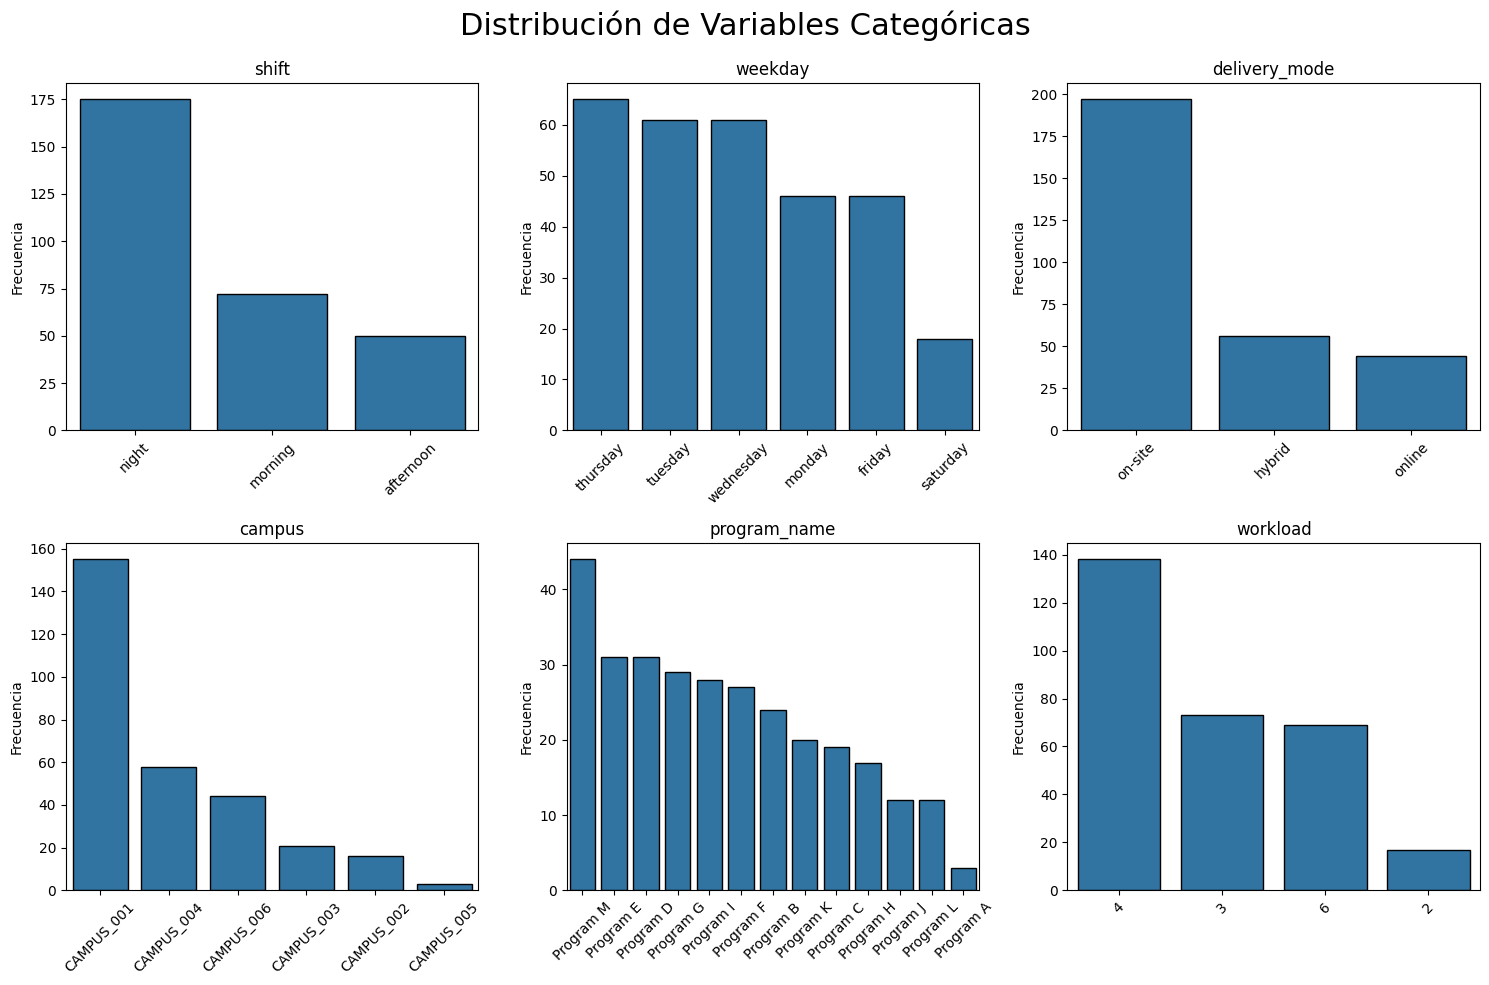

In [5]:
# seleccionar variables categóricas
cat_cols = [
    col for col in df.select_dtypes(include=["object"]).columns
    if df[col].nunique() < 30  # filtro por cantidad de categorías
]
cat_cols += ["workload"]
cat_cols.remove("program_code")

n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()  # simplifica indexado

for i, col in enumerate(cat_cols):
    ax = axes[i]
    order = df[col].value_counts().index
    
    sns.countplot(
        data=df,
        x=col,
        order=order,
        dodge=False,
        edgecolor="black",
        ax=ax
    )

    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia")
    ax.tick_params(axis="x", rotation=45)

# eliminar ejes vacíos (si sobran)
#for j in range(i + 1, len(axes)):
#    fig.delaxes(axes[j])

plt.suptitle("Distribución de Variables Categóricas", fontsize=22)
plt.tight_layout(rect=(0, 0, 1, 0.99))
plt.show()

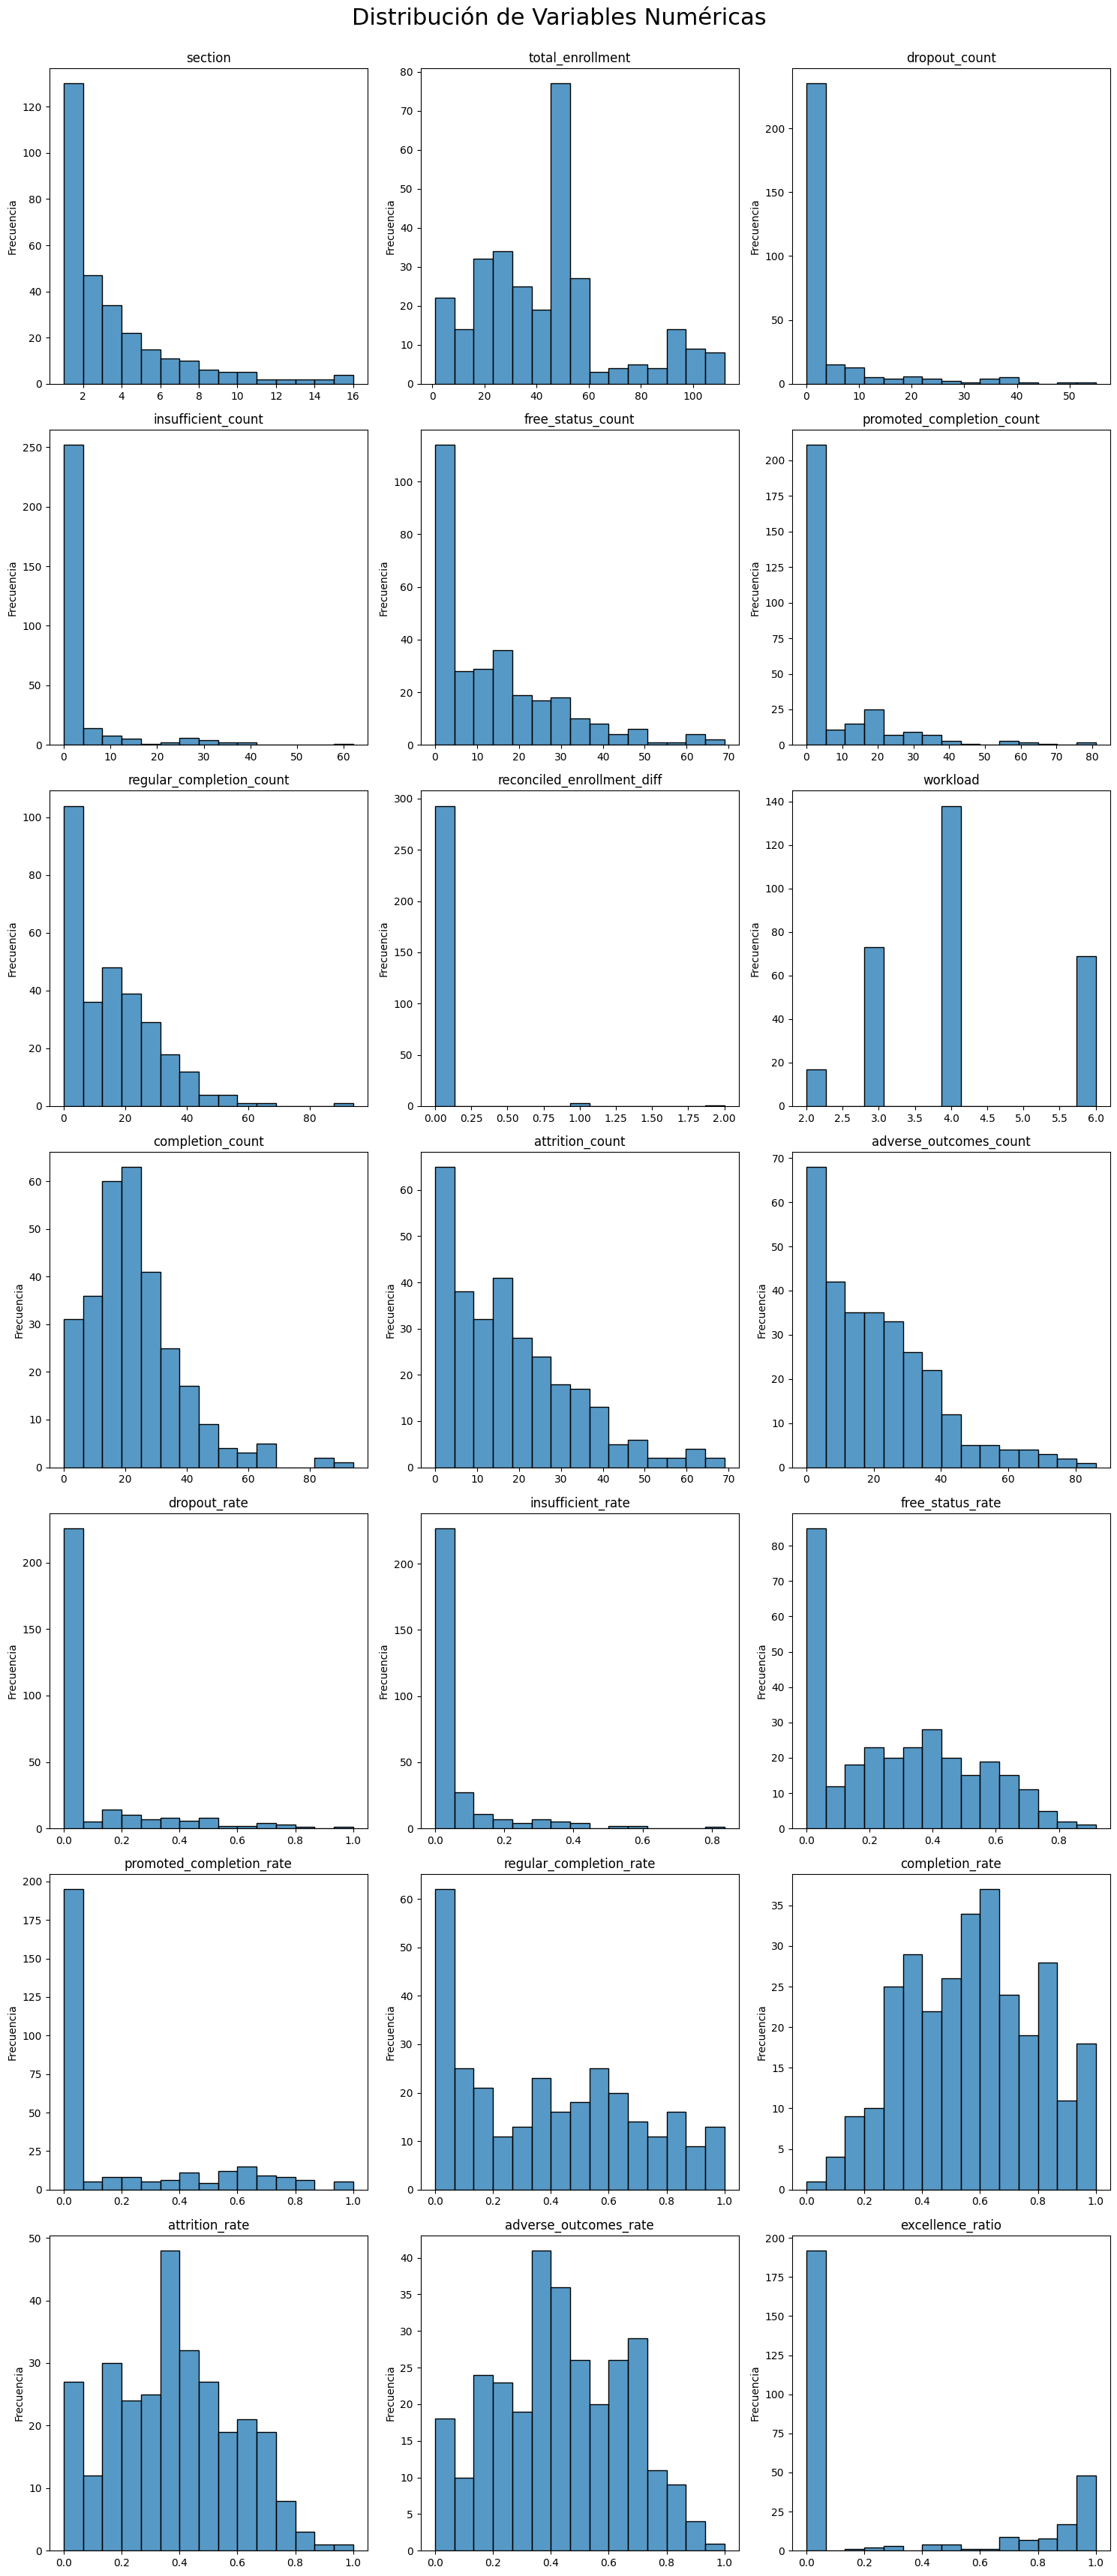

In [6]:
# seleccionar variables numéricas
int_cols = df.select_dtypes(include=[np.number]).columns

n_cols = 3
n_rows = math.ceil(len(int_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(int_cols):
    ax = axes[i]
    
    sns.histplot(data=df, x=col, bins=15, edgecolor="black", ax=ax)
    
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia")

# eliminar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribución de Variables Numéricas", fontsize=22)
plt.tight_layout(rect=(0, 0, 1, 0.98))
plt.show()

a realizar:
* rates por carrera, cursos con mayor abandono, promoted
* correlación entre workload y rates
* rates entre shifts
* rates entre deliveries
* rates por campus
* rates entre weekday
* heatmap de correlaciones entre numéricas

In [7]:
rate_cols = df.select_dtypes(include=[np.number]).columns
rate_cols = rate_cols[rate_cols.str.endswith(("_rate", "_ratio"))]
rate_cols

Index(['dropout_rate', 'insufficient_rate', 'free_status_rate', 'promoted_completion_rate', 'regular_completion_rate', 'completion_rate',
       'attrition_rate', 'adverse_outcomes_rate', 'excellence_ratio'],
      dtype='object')

## Rates by program

In [8]:
rates_by_program = df.groupby("program_name")[rate_cols].agg(["count", "mean", "std"])
rates_by_program

dropout_rate           insufficient_rate           free_status_rate           promoted_completion_rate            \
                    count mean  std             count mean  std            count mean  std                    count mean  std   
program_name                                                                                                                    
Program A               3 0.24 0.42                 3 0.03 0.05                3 0.21 0.19                        3 0.09 0.16   
Program B              24 0.09 0.17                24 0.11 0.14               24 0.22 0.18                       24 0.16 0.23   
Program C              19 0.08 0.19                19 0.06 0.12               19 0.34 0.23                       19 0.19 0.28   
Program D              31 0.13 0.25                31 0.07 0.14               31 0.27 0.24                       31 0.20 0.32   
Program E              31 0.08 0.15                31 0.05 0.13               31 0.30 0.26                       31 0.13 0.27   
Program F              27 0.04 0.17                27 0.03 0.08               27 0.39 0.24                       27 0.11 0.22   
Program G              29 0.12 0.17                29 0.03 0.11               29 0.19 0.23                       29 0.26 0.33   
Program H              17 0.10 0.20                17 0.08 0.13               17 0.33 0.23                       17 0.18 0.25   
Program I              28 0.07 0.15                28 0.08 0.17               28 0.21 0.20                       28 0.14 0.28   
Program J              12 0.01 0.04                12 0.01 0.03               12 0.38 0.32                       12 0.24 0.34   
Program K              20 0.12 0.22                20 0.07 0.11               20 0.24 0.24                       20 0.15 0.28   
Program L              12 0.17 0.28                12 0.01 0.01               12 0.24 0.27                       12 0.32 0.31   
Program M              44 0.06 0.14                44 0.04 0.09               44 0.35 0.23                       44 0.17 0.28   

             regular_completion_rate           completion_rate           attrition_rate           adverse_outcomes_rate            \
                               count mean  std           count mean  std          count mean  std                 count mean  std   
program_name                                                                                                                        
Program A                          3 0.43 0.38               3 0.52 0.22              3 0.45 0.25                     3 0.48 0.22   
Program B                         24 0.44 0.29              24 0.59 0.17             24 0.30 0.16                    24 0.41 0.17   
Program C                         19 0.33 0.30              19 0.52 0.23             19 0.42 0.20                    19 0.48 0.23   
Program D                         31 0.33 0.27              31 0.53 0.22             31 0.40 0.22                    31 0.47 0.22   
Program E                         31 0.45 0.34              31 0.58 0.26             31 0.37 0.24                    31 0.42 0.26   
Program F                         27 0.42 0.31              27 0.54 0.23             27 0.43 0.22                    27 0.46 0.23   
Program G                         29 0.39 0.35              29 0.66 0.20             29 0.31 0.19                    29 0.34 0.20   
Program H                         17 0.32 0.32              17 0.49 0.23             17 0.43 0.19                    17 0.51 0.23   
Program I                         28 0.49 0.29              28 0.64 0.21             28 0.28 0.20                    28 0.36 0.21   
Program J                         12 0.36 0.33              12 0.60 0.31             12 0.39 0.31                    12 0.40 0.31   
Program K                         20 0.41 0.31              20 0.56 0.24             20 0.36 0.22                    20 0.44 0.24   
Program L                         12 0.26 0.36              12 0.59 0.27             1

### Dropout

In [9]:
dropout_by_program = rates_by_program.loc[:, "dropout_rate"].reset_index().sort_values("mean", ascending=False)
dropout_by_program

,program_name,count,mean,std
0,Program A,3,0.24,0.42
11,Program L,12,0.17,0.28
3,Program D,31,0.13,0.25
10,Program K,20,0.12,0.22
6,Program G,29,0.12,0.17
7,Program H,17,0.10,0.20
1,Program B,24,0.09,0.17
2,Program C,19,0.08,0.19
4,Program E,31,0.08,0.15
8,Program I,28,0.07,0.15


### Attrition

In [10]:
attrition_by_program = rates_by_program.loc[:, "attrition_rate"].reset_index().sort_values("mean", ascending=False)
attrition_by_program

,program_name,count,mean,std
0,Program A,3,0.45,0.25
5,Program F,27,0.43,0.22
7,Program H,17,0.43,0.19
2,Program C,19,0.42,0.20
11,Program L,12,0.41,0.27
12,Program M,44,0.41,0.19
3,Program D,31,0.40,0.22
9,Program J,12,0.39,0.31
4,Program E,31,0.37,0.24
10,Program K,20,0.36,0.22


### Completion

In [11]:
completion_by_program = rates_by_program.loc[:, "completion_rate"].reset_index().sort_values("mean", ascending=False)
completion_by_program

,program_name,count,mean,std
6,Program G,29,0.66,0.20
8,Program I,28,0.64,0.21
9,Program J,12,0.60,0.31
1,Program B,24,0.59,0.17
11,Program L,12,0.59,0.27
4,Program E,31,0.58,0.26
10,Program K,20,0.56,0.24
12,Program M,44,0.55,0.20
5,Program F,27,0.54,0.23
3,Program D,31,0.53,0.22


### Excellence

In [12]:
excellence_by_program = rates_by_program.loc[:, "excellence_ratio"].reset_index().sort_values("mean", ascending=False)
excellence_by_program

,program_name,count,mean,std
11,Program L,12,0.53,0.48
6,Program G,29,0.40,0.46
7,Program H,17,0.37,0.47
2,Program C,19,0.34,0.44
0,Program A,3,0.33,0.58
9,Program J,12,0.33,0.41
3,Program D,31,0.30,0.45
1,Program B,24,0.29,0.38
12,Program M,44,0.26,0.40
10,Program K,20,0.26,0.40


## Rates by workload

### Completion

In [13]:
completion_by_workload = rate_groups(df, "completion_rate", "workload")

,workload,count,mean,std
2,4,138,0.64,0.21
0,2,17,0.54,0.26
3,6,69,0.53,0.24
1,3,73,0.49,0.19


## Rates by shift

### Completion

In [14]:
completion_by_shift = rate_groups(df, "completion_rate", "shift")

,shift,count,mean,std
2,night,175,0.61,0.23
1,morning,72,0.53,0.21
0,afternoon,50,0.51,0.21


## Rates by campus

### Completion

In [15]:
completion_by_campus = rate_groups(df, "completion_rate", "campus")

,campus,count,mean,std
4,CAMPUS_005,3,1.00,0.00
2,CAMPUS_003,21,0.68,0.26
1,CAMPUS_002,16,0.65,0.17
5,CAMPUS_006,44,0.59,0.20
3,CAMPUS_004,58,0.58,0.21
0,CAMPUS_001,155,0.53,0.22


### Excellence

In [16]:
excellence_by_campus = rate_groups(df, "excellence_ratio", "campus")

,campus,count,mean,std
1,CAMPUS_002,16,0.72,0.44
5,CAMPUS_006,44,0.34,0.43
3,CAMPUS_004,58,0.27,0.42
2,CAMPUS_003,21,0.26,0.41
0,CAMPUS_001,155,0.26,0.40
4,CAMPUS_005,3,0.00,0.00


In [17]:
df[df["campus"]=="CAMPUS_005"]

,course_name,section,total_enrollment,dropout_count,insufficient_count,free_status_count,promoted_completion_count,regular_completion_count,course_code,program_code,is_reconciled,reconciled_enrollment_diff,workload,shift,weekday,schedule_time,delivery_mode,campus,program_name,completion_count,attrition_count,adverse_outcomes_count,dropout_rate,insufficient_rate,free_status_rate,promoted_completion_rate,regular_completion_rate,completion_rate,attrition_rate,adverse_outcomes_rate,excellence_ratio
285,COURSE 079,1,16,0,0,0,0,16,CRS_079,PRG_002,False,0,4,morning,wednesday,8 a 13,on-site,CAMPUS_005,Program B,16,0,0,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00
286,COURSE 078,1,16,0,0,0,0,16,CRS_078,PRG_005,False,0,6,morning,monday,8 a 13,hybrid,CAMPUS_005,Program E,16,0,0,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00
287,COURSE 077,1,16,0,0,0,0,16,CRS_077,PRG_012,False,0,2,morning,friday,8 a 10,on-site,CAMPUS_005,Program L,16,0,0,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00


## Rates by weekday

### Completion

In [18]:
completion_by_weekday = rate_groups(df, "completion_rate", "weekday")

,weekday,count,mean,std
1,monday,46,0.61,0.23
5,wednesday,61,0.59,0.23
0,friday,46,0.58,0.21
3,thursday,65,0.57,0.22
4,tuesday,61,0.54,0.24
2,saturday,18,0.49,0.22


## Rates by delivery mode

### Completion

In [19]:
completion_by_delivery_mode = rate_groups(df, "completion_rate", "delivery_mode")

,delivery_mode,count,mean,std
2,online,44,0.59,0.20
1,on-site,197,0.59,0.22
0,hybrid,56,0.49,0.24


a realizar:
* analizar los distintos completion rates por categoría (weekday, campus, shift y delivery_mode) para las distintas carreras, y ver si hay algún caso particular (una configuración carrera-modalidad(o campus, o shift o weekday) con una tasa muy alta o muy baja)

## Idea: ver los grupos con mejor completion_rate

In [20]:
all_in = df.groupby(["workload", "campus", "delivery_mode", "weekday", "shift"])["completion_rate"].agg(["count", "mean"]).reset_index()
all_in.sort_values("mean", ascending=False)

,workload,campus,delivery_mode,weekday,shift,count,mean
7,2,CAMPUS_003,on-site,wednesday,night,1,1.00
9,2,CAMPUS_005,on-site,friday,morning,1,1.00
117,6,CAMPUS_005,hybrid,monday,morning,1,1.00
110,6,CAMPUS_003,hybrid,thursday,night,1,1.00
111,6,CAMPUS_003,hybrid,wednesday,night,1,1.00
84,4,CAMPUS_005,on-site,wednesday,morning,1,1.00
73,4,CAMPUS_002,on-site,wednesday,night,1,1.00
76,4,CAMPUS_003,on-site,thursday,night,2,0.89
6,2,CAMPUS_001,on-site,wednesday,night,1,0.87
69,4,CAMPUS_002,on-site,monday,night,1,0.86


## Idea: ver las distribuciones de completion_rate entre las distintas categorías
Para elegir las que más variación infraclase tengan y realizar un heatmap posterior

C:\Users\Estudio\AppData\Local\Temp\ipykernel_7132\2562588550.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
C:\Users\Estudio\AppData\Local\Temp\ipykernel_7132\2562588550.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
C:\Users\Estudio\AppData\Local\Temp\ipykernel_7132\2562588550.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
C:\Users\Estudio\AppData\Local\Temp\ipykernel_7132\2562588550.py:8: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\Estudio\AppData\Local\Temp\ipyker

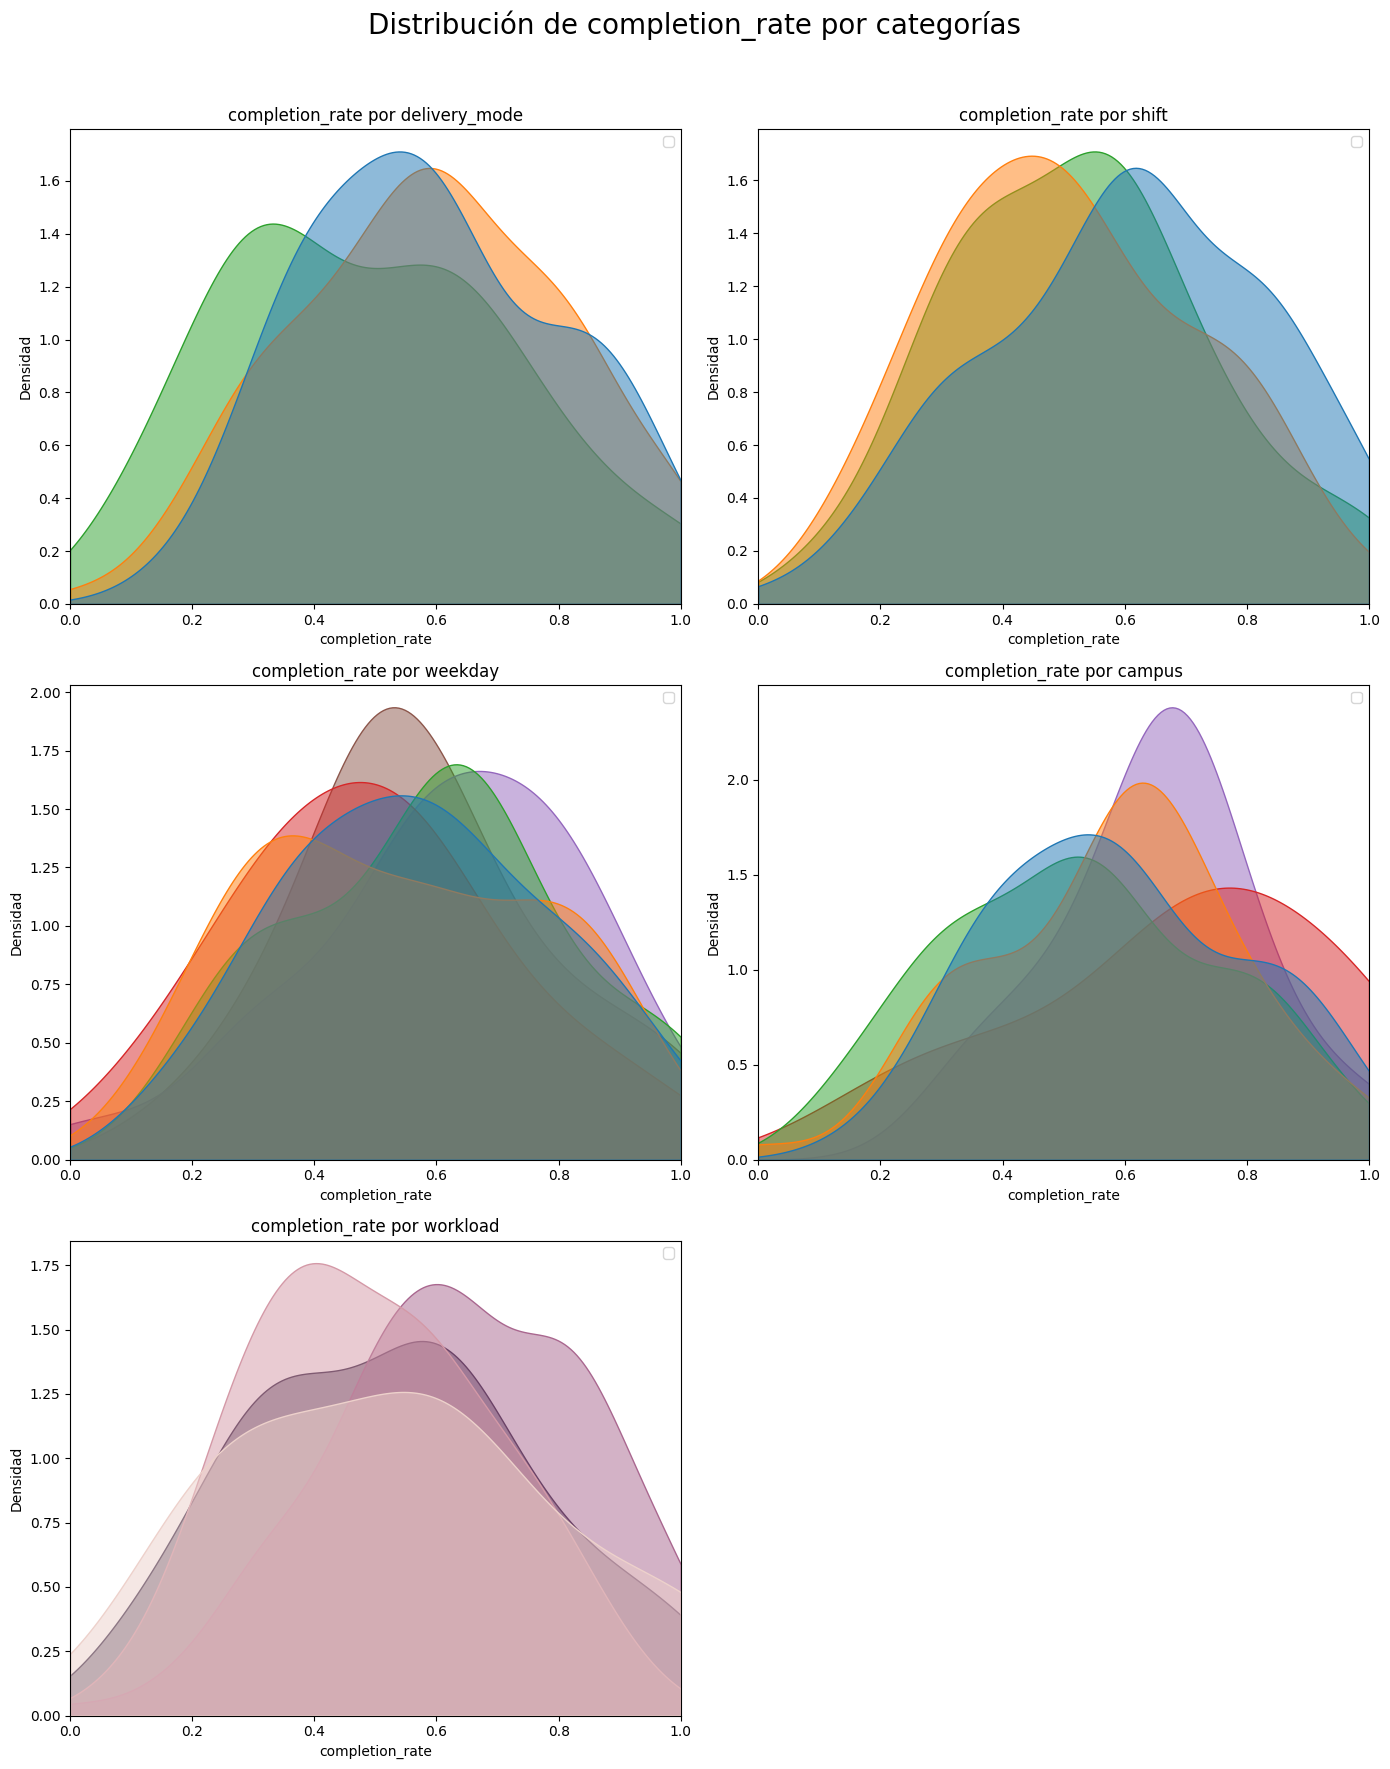

In [21]:
fig, axes = plt.subplots(3, 2, figsize=(14, 18))
axes = axes.flatten()

cat_vars = ["delivery_mode", "shift", "weekday", "campus", "workload"]

for i, col in enumerate(cat_vars):
    ax = axes[i]
    sns.kdeplot(
        data=df,
        x="completion_rate",
        hue=col,
        common_norm=False,
        fill=True,
        alpha=0.5,
        clip=(0, 1),
        ax=ax
    )
    ax.set_xlim(0, 1)
    ax.set_title(f"completion_rate por {col}")
    ax.set_xlabel("completion_rate")
    ax.set_ylabel("Densidad")
    ax.legend()

axes[-1].set_visible(False)

plt.suptitle("Distribución de completion_rate por categorías", fontsize=20)
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

## Heatmaps entre categorías y completion_rate

In [22]:
cat_cols.remove("program_name")
cat_cols

['shift', 'weekday', 'delivery_mode', 'campus', 'workload']

shift      weekday  
afternoon  wednesday    14
           thursday     12
           tuesday      12
           monday        7
           friday        5
morning    saturday     18
           thursday     12
           tuesday      12
           friday       11
           monday       10
           wednesday     9
night      thursday     41
           wednesday    38
           tuesday      37
           friday       30
           monday       29
Name: count, dtype: int64

shift      delivery_mode
afternoon  on-site           29
           online            11
           hybrid            10
morning    on-site           52
           hybrid            15
           online             5
night      on-site          116
           hybrid            31
           online            28
Name: count, dtype: int64

shift      campus    
afternoon  CAMPUS_001    35
           CAMPUS_006    11
           CAMPUS_002     4
morning    CAMPUS_001    56
           CAMPUS_002     5
           CAMPUS_006     5
           CAMPUS_004     3
           CAMPUS_005     3
night      CAMPUS_001    64
           CAMPUS_004    55
           CAMPUS_006    28
           CAMPUS_003    21
           CAMPUS_002     7
Name: count, dtype: int64

shift      workload
afternoon  4           20
           3           15
           6           11
           2            4
morning    4           29
           3           19
           6           19
           2            5
night      4           89
           3           39
           6           39
           2            8
Name: count, dtype: Int64

weekday    delivery_mode
friday     on-site          33
           hybrid           10
           online            3
monday     on-site          36
           hybrid            8
           online            2
saturday   on-site          15
           hybrid            2
           online            1
thursday   on-site          44
           online           13
           hybrid            8
tuesday    on-site          31
           online           17
           hybrid           13
wednesday  on-site          38
           hybrid           15
           online            8
Name: count, dtype: int64

weekday    campus    
friday     CAMPUS_001    22
           CAMPUS_004    12
           CAMPUS_002     6
           CAMPUS_006     3
           CAMPUS_003     2
           CAMPUS_005     1
monday     CAMPUS_001    25
           CAMPUS_004    11
           CAMPUS_003     6
           CAMPUS_006     2
           CAMPUS_002     1
           CAMPUS_005     1
saturday   CAMPUS_001    14
           CAMPUS_004     3
           CAMPUS_006     1
thursday   CAMPUS_001    33
           CAMPUS_006    13
           CAMPUS_004     7
           CAMPUS_002     6
           CAMPUS_003     6
tuesday    CAMPUS_001    29
           CAMPUS_006    17
           CAMPUS_004    12
           CAMPUS_003     3
wednesday  CAMPUS_001    32
           CAMPUS_004    13
           CAMPUS_006     8
           CAMPUS_003     4
           CAMPUS_002     3
           CAMPUS_005     1
Name: count, dtype: int64

weekday    workload
friday     4           22
           3           12
           6           11
           2            1
monday     4           31
           6            9
           3            6
saturday   4            8
           3            5
           6            5
thursday   4           29
           3           19
           6           11
           2            6
tuesday    4           24
           3           16
           6           15
           2            6
wednesday  4           24
           6           18
           3           15
           2            4
Name: count, dtype: Int64

delivery_mode  campus    
hybrid         CAMPUS_001     41
               CAMPUS_004     11
               CAMPUS_003      3
               CAMPUS_005      1
on-site        CAMPUS_001    114
               CAMPUS_004     47
               CAMPUS_003     18
               CAMPUS_002     16
               CAMPUS_005      2
online         CAMPUS_006     44
Name: count, dtype: int64

delivery_mode  workload
hybrid         6            50
               2             5
               4             1
on-site        4           125
               3            62
               2             7
               6             3
online         6            16
               4            12
               3            11
               2             5
Name: count, dtype: Int64

campus      workload
CAMPUS_001  4           73
            6           38
            3           35
            2            9
CAMPUS_002  3            8
            4            8
CAMPUS_003  3            9
            4            8
            6            3
            2            1
CAMPUS_004  4           36
            6           11
            3           10
            2            1
CAMPUS_005  2            1
            4            1
            6            1
CAMPUS_006  6           16
            4           12
            3           11
            2            5
Name: count, dtype: Int64

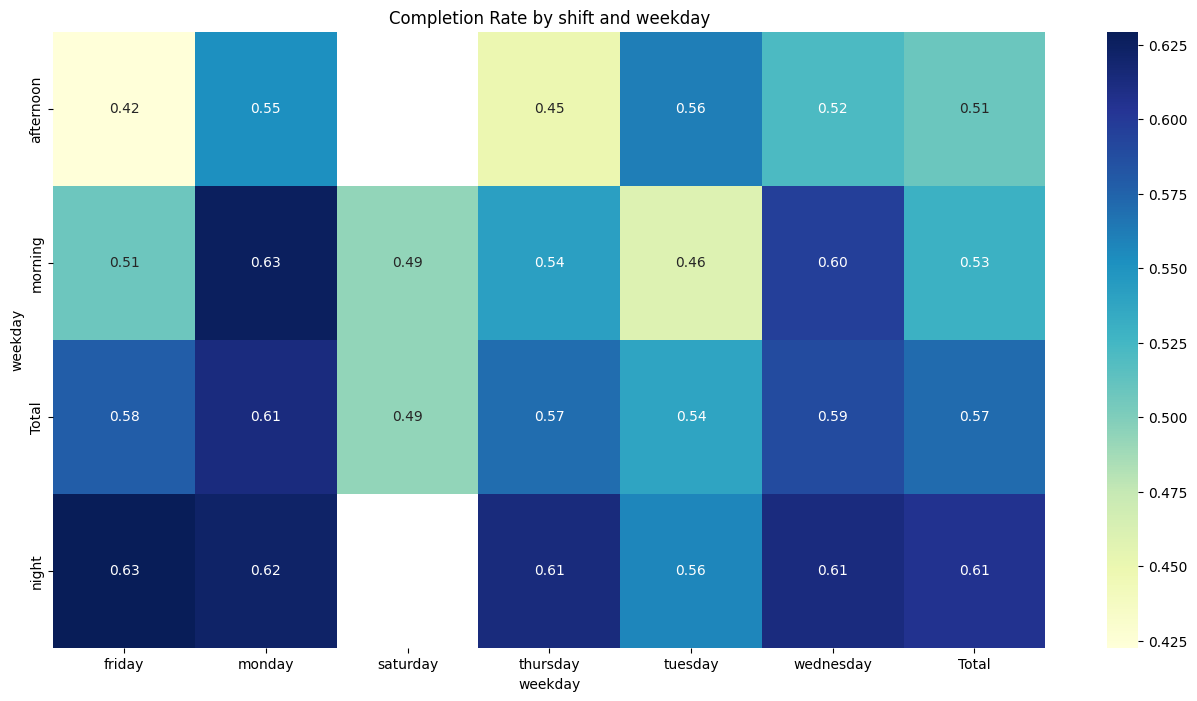

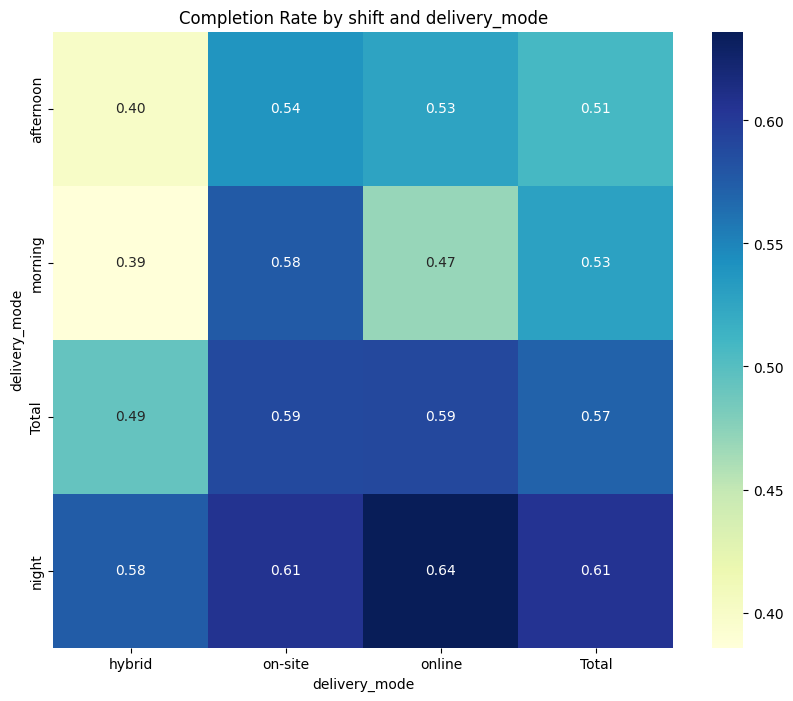

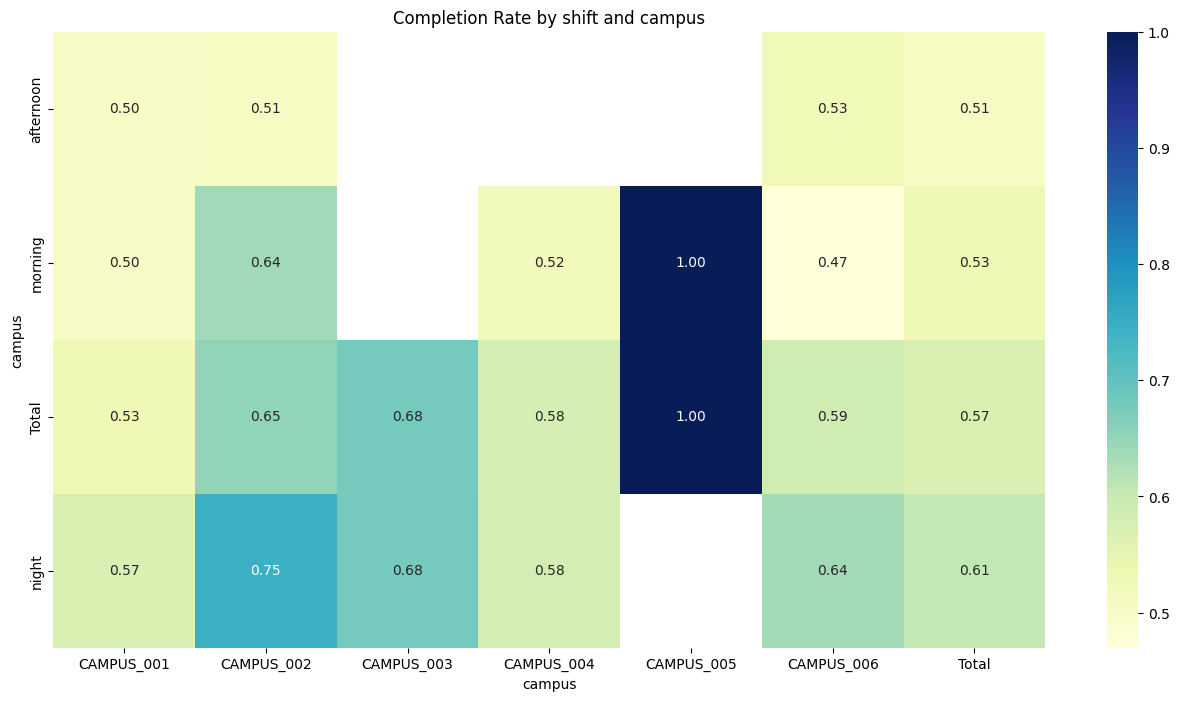

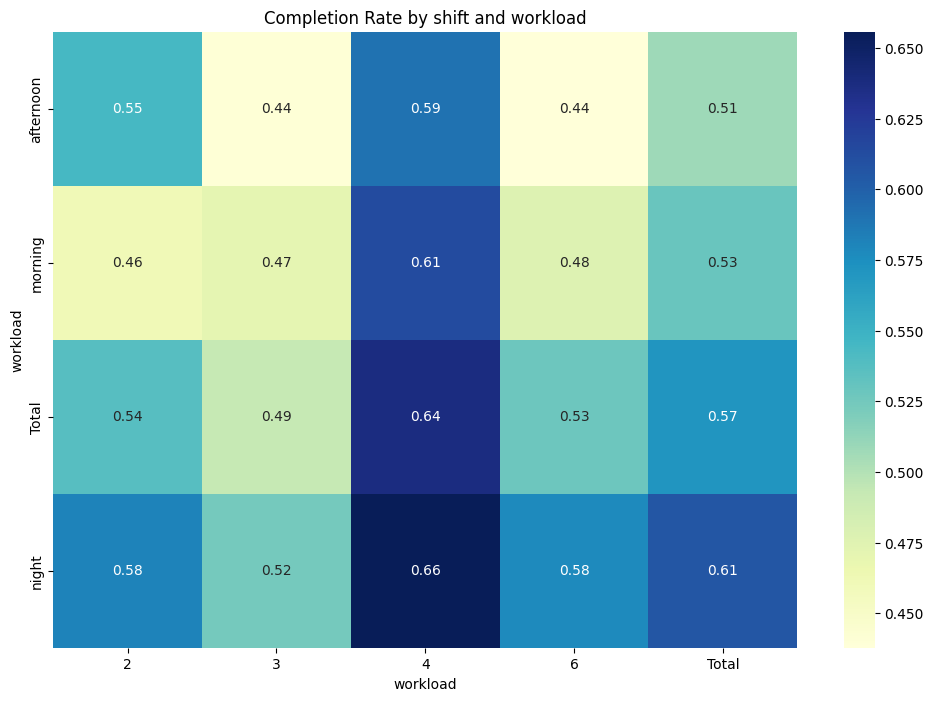

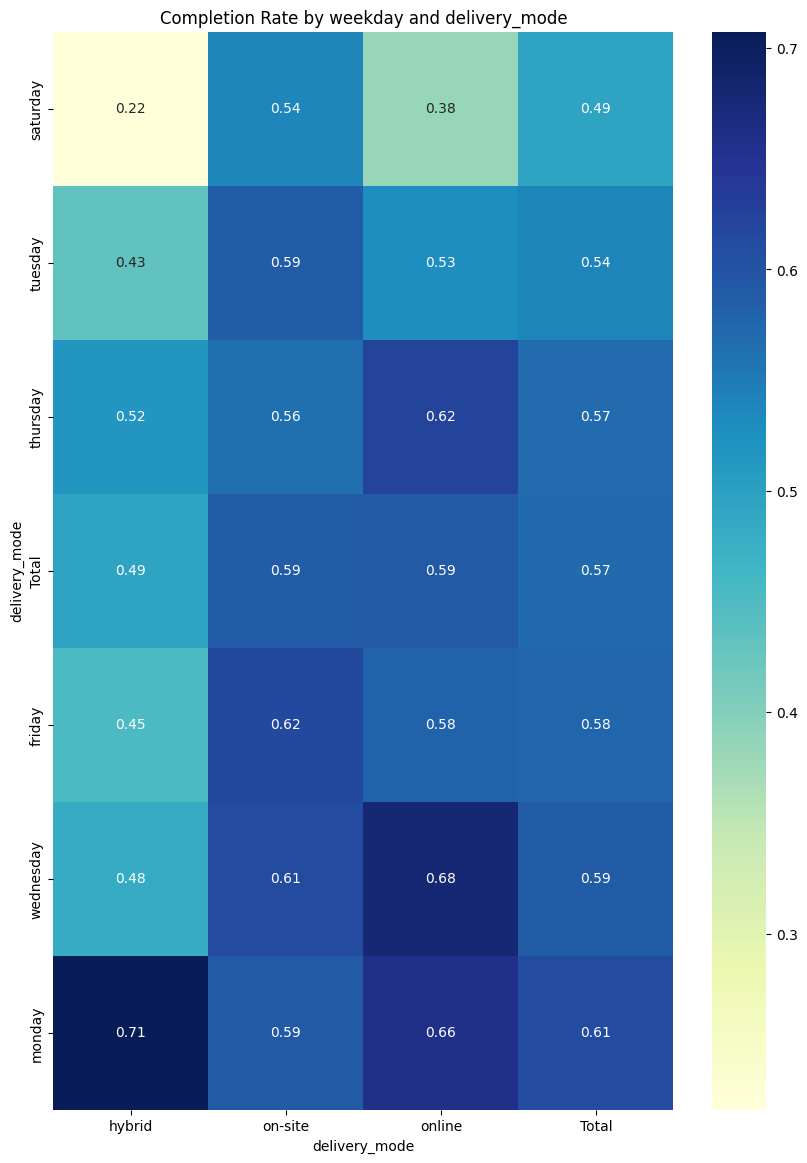

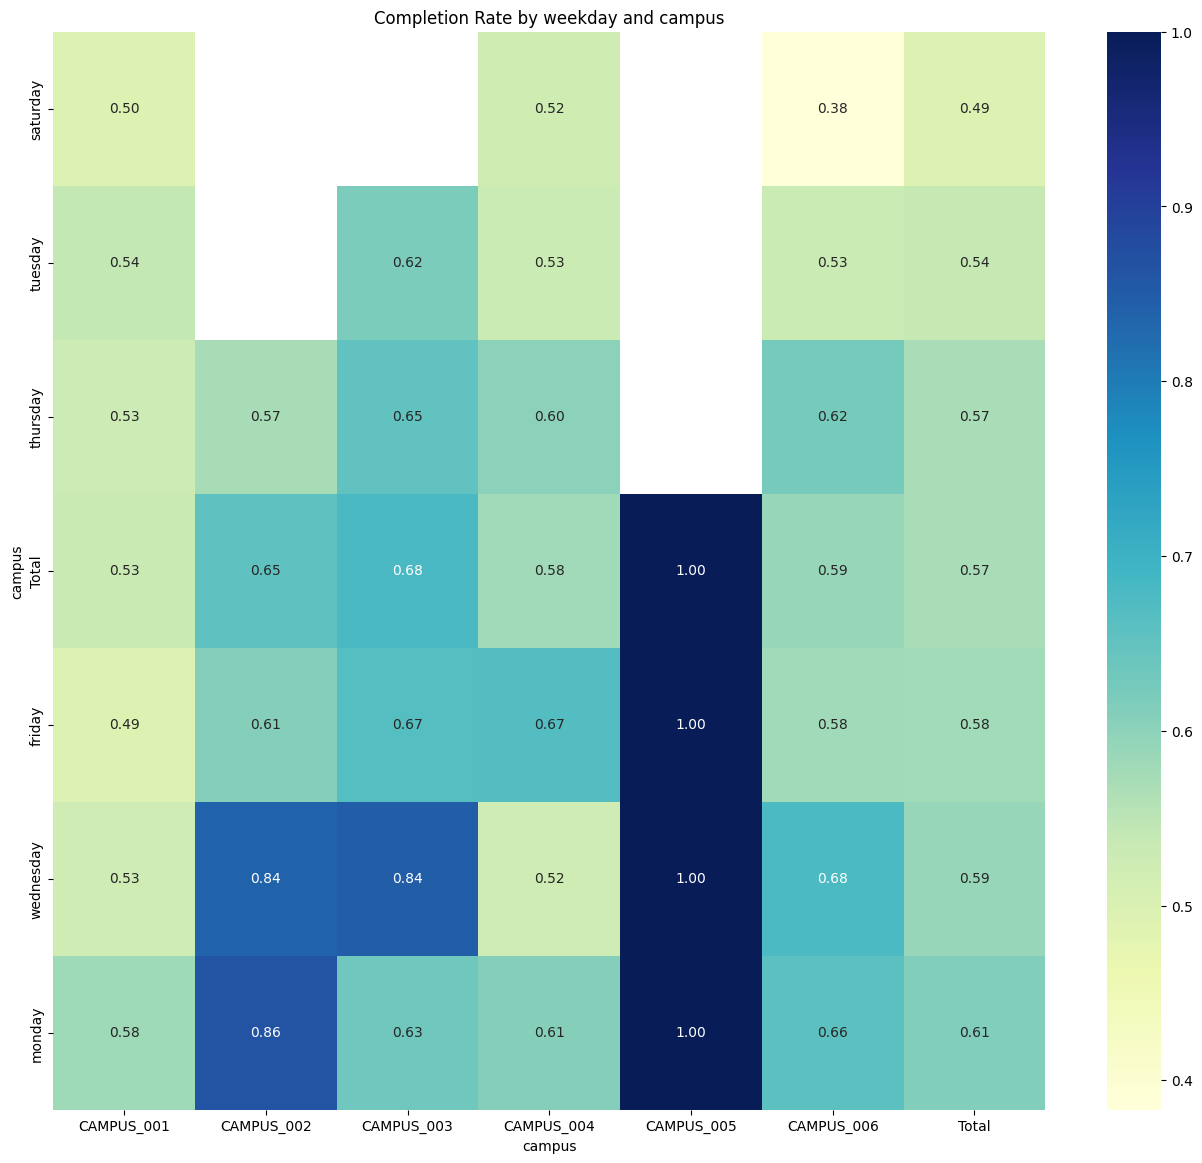

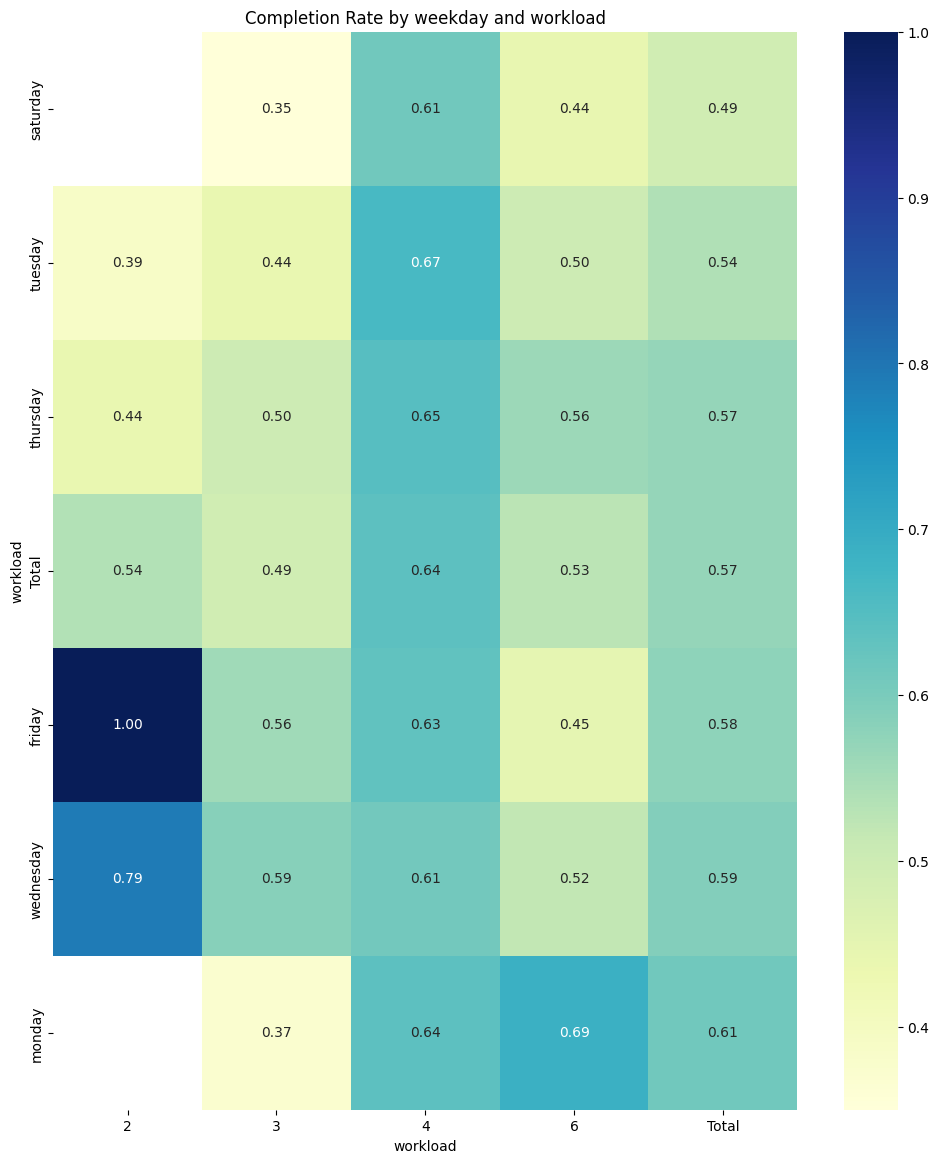

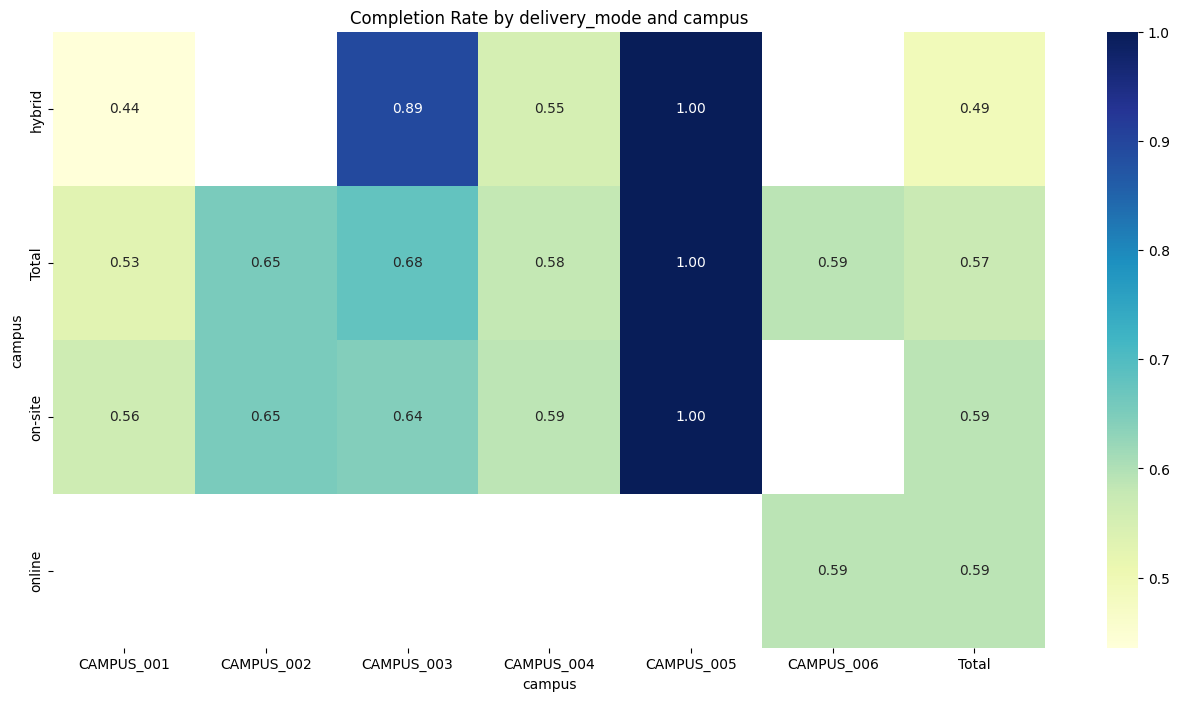

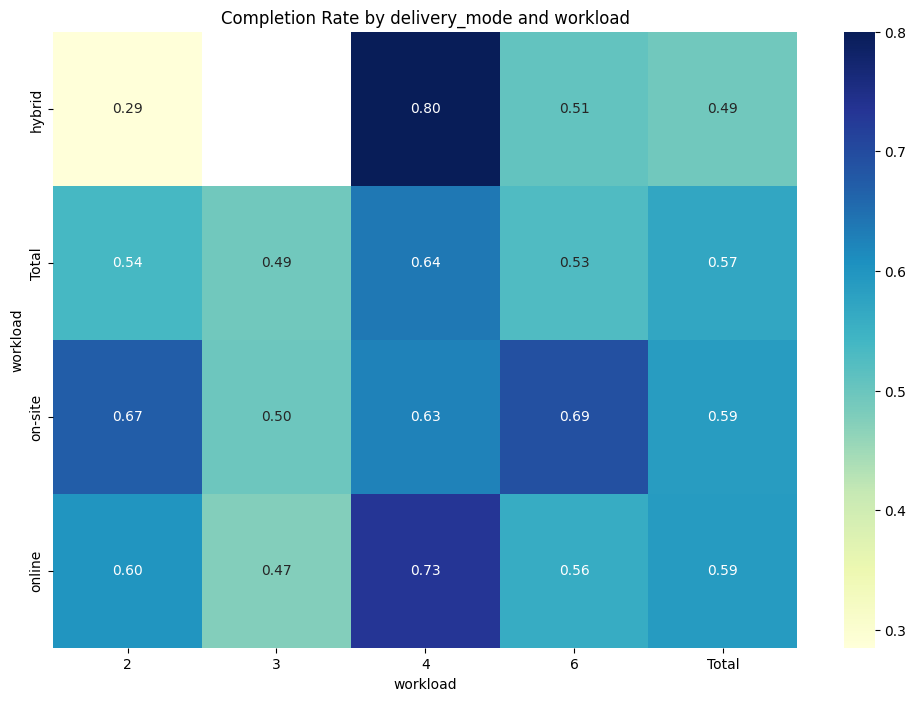

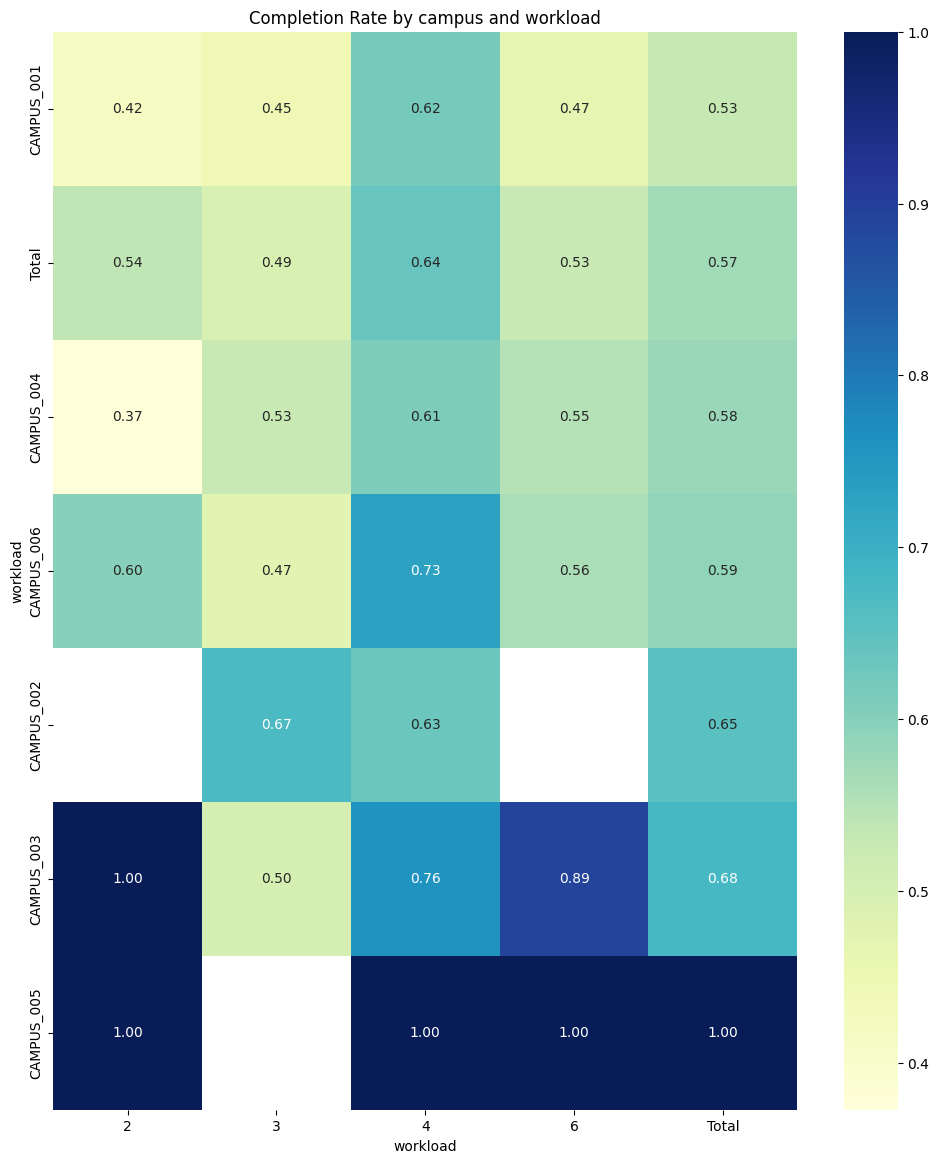

In [23]:
for i, col1 in enumerate(cat_cols):
    for j, col2 in enumerate(cat_cols):
        if j>i:
            table = df.pivot_table("completion_rate", col1, col2, margins=True, margins_name="Total")
            table.sort_values("Total", inplace=True)
            display(df.groupby(col1)[col2].value_counts())
            w = 4 + 2*df[col2].nunique()
            h = 2 + 2*df[col1].nunique()
            plt.figure(figsize=(w, h))
            sns.heatmap(table, annot=True, cmap="YlGnBu", fmt=".2f")
            plt.title(f"Completion Rate by {col1} and {col2}")
            plt.xlabel(col2)
            plt.ylabel(col2)
            plt.savefig(f"reports/figures/completion_rate_heatmap_{col1}_and_{col2}.png", bbox_inches="tight")